<a href="https://colab.research.google.com/github/armaant06/DS2501-Final-Project/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anamika Pusalkar, Chelsea Kwan, and Armaan Thomas

DS 2500

Final Project

FinalProject.py

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Functions to call and clean data - Anamika

In [ ]:
def load_data(filepath):
    """
    parameters:
        * filepath: path to file, str
    does:
        * loads in data from either Google Drive or local environment
    returns:
        * data: dataframe with loaded data
    """
    try:
        # Loading from Google Drive (Colab)
        from google.colab import drive
        drive.mount("/content/drive")
        data = pd.read_csv(filepath)

    except:
        # Fallback for local environment (e.g., Gradescope)
        filepath = "collisions.csv"
        data = pd.read_csv(filepath)

    return data

def clean_data(data):
    """
    parameters:
        * data: dataframe to clean
    does:
        * cleans data by removing unnecessary columns and changing data types
    returns:
        * data: cleaned dataframe
    """
    # removing columns we're not interested in
    data = data.drop("LATITUDE", axis = 1)
    data = data.drop("LONGITUDE", axis = 1)
    data = data.drop("LOCATION", axis = 1)
    data = data.drop("ZIP CODE", axis = 1)
    data = data.drop("COLLISION_ID", axis = 1)

    # returning result
    return data

Functions for time and season analysis and visualization - Armaan

In [ ]:
def time_of_day(data):
    """
    parameters:
      * data: dataframe with all data
    does:
      * initializes 4 lists for times of day and interates through the data
      variable, assigning crash timestamps to their respective time-of-day lists
    returns:
      * The lengths of each time-of-day list
    """
    # initializing 4 empty lists by time of day
    morning = []
    afternoon = []
    evening = []
    night = []

    # isolates the timestamp column of data
    times = data['CRASH TIME']

    # iterates through each row in the timestamps column, splits it by a ":",
    # and assigns hour and minute int variables based on their index value
    # relative to the colon
    for item in times:
        segment = item.split(':')
        hour = int(segment[0])
        minute = int(segment[1])

        # a series of if/elif statements to divide the timestamps into their
        # respective list groupings
        if (hour >= 6) and (hour <= 11 and minute <= 59):
            morning.append(item)
        elif (hour >= 12) and (hour <= 17 and minute <= 59):
            afternoon.append(item)
        elif (hour >= 18) and (hour <= 23 and minute <= 59):
            evening.append(item)
        elif (hour >= 00) and (hour <= 5 and minute <= 59):
            night.append(item)

    # returns the length of each list, aka the number of crashes for each
    # time of day group
    return len(morning), len(afternoon), len(evening), len(night), len(times)

def time_of_year(data):
    """
    parameters:
      * data: dataframe with all data
    does:
      * initializes 4 lists for times of year and interates through the data
      variable, assigning crash timestamps to their respective time-of-year lists
    returns:
      * The lengths of each time-of-day list
    """
    spring = []
    summer = []
    fall = []
    winter = []
    seasons = data['CRASH DATE']
    for item in seasons:
        month = item.strip().split('/')[0]
        if month in ('01', '02', '12'):
            winter.append(month)
        elif month in ('03', '04', '05'):
            spring.append(month)
        elif month in ('06', '07', '08'):
            summer.append(month)
        elif month in ('09', '10', '11'):
            fall.append(month)
    return len(winter), len(spring), len(summer), len(fall), len(seasons)

Functions for location analysis and visualization - Chelsea

In [ ]:
def borough(data):
    # identify number of crashes per borough
    bor = data["BOROUGH"].value_counts()
    return bor

def borough_vis(bor):
    # plot borough data
    plt.figure(figsize=(8, 6))
    plt.bar(bor.index, bor.values)
    plt.title('Motor Accidents by Borough')
    plt.xlabel('Borough')
    plt.ylabel('Number of Accidents')
    plt.grid(True)
    plt.show()

def intersection(data):
    # identify main and cross streets
    main_street = 'ON STREET NAME'
    cross_street = 'CROSS STREET NAME'

    # join information together
    intersect = data.value_counts(subset = [main_street, cross_street])

    # print top 5 interesections w/ most crashes
    print(intersect.head())

    return intersect

Functions for vehicle type analysis and visualization - Chelsea

In [ ]:
def clean_word(vehicle):
    # identify common punctation
    punctuation = [".", ",", "/", "-", "_"]

    # intialize string
    cleaned = ""

    # work through each word
    for element in vehicle:
        if element in punctuation:
            cleaned += " "
        else:
            cleaned += element

    return cleaned

def clean_input(vehicle):
    # identify common words
    common_words = ["vehicle"]

    if not isinstance(vehicle, str):
        return vehicle

    # clean word
    cleaned = clean_word(vehicle)
    parts = cleaned.lower().split()

    # clean phrase
    cleaned_phrase = []
    for word in parts:
        if word in common_words:
            word = ""
        else:
            cleaned_phrase.append(word)
    cleaned_phrase.sort()

    return " ".join(cleaned_phrase)

def vehicle_type(data):
    # join all vehicle type columns
    for i in range(5):
        code = "VEHICLE TYPE CODE " + str(i + 1)
        vehicle_types = data[code].apply(clean_input).value_counts()

    # add all data frames together for one cohesive data frame with all vehicle
    # types
        if i+1 == 1:
            total_vehicle_types = vehicle_types
        else:
            total_vehicle_types += vehicle_types

    total_vehicle_types = total_vehicle_types.dropna(axis = 0).astype(int)
    return total_vehicle_types

def vehicle_type_vis(total_vehicle_types):
    # plot common vehicle data
    plt.figure(figsize = (8, 6))
    plt.bar(total_vehicle_types.head().index, total_vehicle_types.head().values)
    plt.title('Motor Accidents by Vehicle Type')
    plt.xlabel('Vehicle Type')
    plt.ylabel('Number of Accidents')
    plt.grid(True)
    plt.show()

Functions for contributing factors analysis - Anamika

In [ ]:
def cont_facts(data, cols):
    """
    Parameters:
        * data: dataframe with all data
        * cols: relevant columns
    Does:
        * removes irrelevant factors and creates series of contributing
        factors by frequency
    Returns:
        * len(cont_factors): how many total factors, an int
        * freq: series of contributing factors by frequency
    """
    # creating a list of contributing factors, removing the ones irrelevant
    # to us
    cont_factors = []

    for col in cols:
        factors = data[col].dropna()
        factors = factors[factors != ""]
        factors = factors[factors != "Unspecified"]
        factors = factors[factors != "Other Vehicular"]
        cont_factors.extend(factors.tolist())

    # converting the list to a series
    cont_factors_series = pd.Series(cont_factors)

    # identifying the most frequent contributing factors
    freq = cont_factors_series.value_counts()

    # returning results
    return len(cont_factors), freq

Functions for injuries and casualties by pedestrian, cyclist, and motorist analysis and

visualization - Anamika

In [ ]:
def descriptives(data, col_name):
  """
  Parameters:
      * data: dataframe
      * col_name: name of column to analyze in dataframe (str)
  Does:
      * calculates descriptive statistics for given column
  Returns:
      * results: dictionary of descriptive statistics
  """
  col = data[col_name].dropna()

  results = {"mean": col.mean(),
           "median": col.median(),
           "mode": col.mode()[0] if not col.mode().empty else None,
           "std": col.std(),
           "min": col.min(),
           "max": col.max(),
           "range": col.max() - col.min(),
           "total": col.sum(),
           "count": len(col)}

  return results

def print_stats(cat_name, stats):
  """
  Parameters:
      * cat_name: name of the category (str)
      * stats: statistics (dict from descriptives())
  Does:
      * prints formatted statistics for a category
  Returns:
      * nothing, instead prints statements
  """
  print(f"\nDescriptive statistics for {cat_name}:")
  print(f"Mean: {stats['mean']:.2f}")
  print(f"Median: {stats['median']:.2f}")
  print(f"Mode: {stats['mode']}")
  print(f"Std Dev: {stats['std']:.2f}")
  print(f"Min: {stats['min']}")
  print(f"Max: {stats['max']}")
  print(f"Range: {stats['range']}")
  print(f"Total: {stats['total']}")
  print(f"Sample Size: {stats['count']}")

def type_casualty_vis(data):
  """
  Parameters:
      * data: dataframe
  Does:
      * visualizes injury and death statistics by mean and total count via
        bar plot
  Returns:
      * nothing, instead shows graph
  """
  pedestrians_injured = data["NUMBER OF PEDESTRIANS INJURED"].dropna()
  cyclists_injured = data["NUMBER OF CYCLIST INJURED"].dropna()
  motorists_injured = data["NUMBER OF MOTORIST INJURED"].dropna()
  pedestrians_killed = data["NUMBER OF PEDESTRIANS KILLED"].dropna()
  cyclists_killed = data["NUMBER OF CYCLIST KILLED"].dropna()
  motorists_killed = data["NUMBER OF MOTORIST KILLED"].dropna()

# create graph
  fig, axes = plt.subplots(2, 2, figsize = (16, 10))

  groups_injured = [pedestrians_injured, cyclists_injured, motorists_injured]
  groups_killed = [pedestrians_killed, cyclists_killed, motorists_killed]
  group_names = ["Pedestrians", "Cyclists", "Motorists"]

  # Row 1: INJURIES
  # Mean
  axes[0, 0].bar(range(3), [group.mean() for group in groups_injured],
                 color = "darkorange")
  axes[0, 0].set_xticks(range(3))
  axes[0, 0].set_xticklabels(group_names)
  axes[0, 0].set_ylabel("Mean")
  axes[0, 0].set_xlabel("Group")
  axes[0, 0].set_title("Mean Injuries per Crash")
  axes[0, 0].grid(True, alpha = 0.4, axis = "y")

  # Total
  axes[0, 1].bar(range(3), [group.sum() for group in groups_injured],
                 color = "darkorange")
  axes[0, 1].set_xticks(range(3))
  axes[0, 1].set_xticklabels(group_names)
  axes[0, 1].set_ylabel("Total Count")
  axes[0, 1].set_xlabel("Group")
  axes[0, 1].set_title("Total Injuries (All Crashes)")
  axes[0, 1].grid(True, alpha = 0.4, axis = "y")
  for i, val in enumerate([group.sum() for group in groups_injured]):
      axes[0, 1].text(i, val, f"{int(val):,}", ha = "center", va = "bottom")

  # Row 2: FATALITIES
  # Mean
  axes[1, 0].bar(range(3), [group.mean() for group in groups_killed],
                 color = "firebrick")
  axes[1, 0].set_xticks(range(3))
  axes[1, 0].set_xticklabels(group_names)
  axes[1, 0].set_ylabel("Mean")
  axes[1, 0].set_xlabel("Group")
  axes[1, 0].set_title("Mean Fatalities per Crash")
  axes[1, 0].grid(True, alpha = 0.4, axis = "y")

  # Total
  axes[1, 1].bar(range(3), [group.sum() for group in groups_killed],
                  color = "firebrick")
  axes[1, 1].set_xticks(range(3))
  axes[1, 1].set_xticklabels(group_names)
  axes[1, 1].set_ylabel("Total Count")
  axes[1, 1].set_xlabel("Group")
  axes[1, 1].set_title("Total Fatalities (All Crashes)")
  axes[1, 1].grid(True, alpha = 0.4, axis = "y")
  for i, val in enumerate([group.sum() for group in groups_killed]):
      axes[1, 1].text(i, val, f"{int(val):,}", ha = "center", va = "bottom")

  plt.tight_layout()
  plt.show()

Main function - Anamika

Mounted at /content/drive


/tmp/ipython-input-3485656628.py:14: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(filepath)


   CRASH DATE CRASH TIME   BOROUGH           ON STREET NAME CROSS STREET NAME  \
0  09/11/2021       2:39       NaN    WHITESTONE EXPRESSWAY         20 AVENUE   
1  03/26/2022      11:45       NaN  QUEENSBORO BRIDGE UPPER               NaN   
2  11/01/2023       1:29  BROOKLYN            OCEAN PARKWAY          AVENUE K   
3  06/29/2022       6:55       NaN       THROGS NECK BRIDGE               NaN   
4  09/21/2022      13:21       NaN          BROOKLYN BRIDGE               NaN   

  OFF STREET NAME  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0             NaN                        2.0                       0.0   
1             NaN                        1.0                       0.0   
2             NaN                        1.0                       0.0   
3             NaN                        0.0                       0.0   
4             NaN                        0.0                       0.0   

   NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  ... 

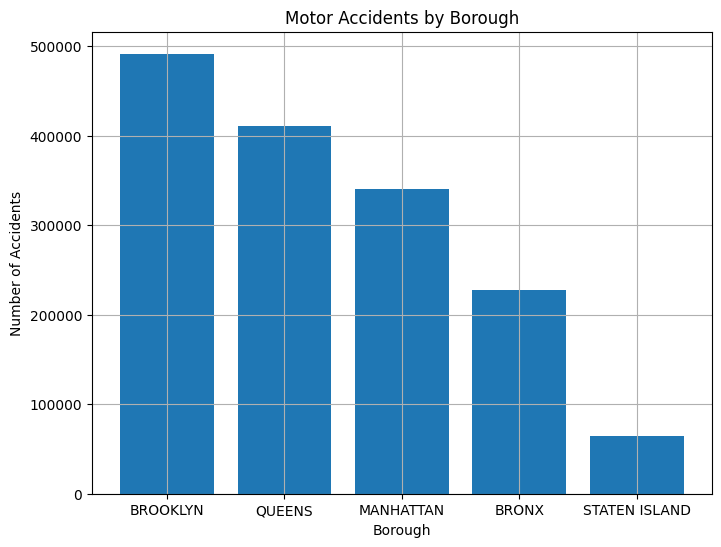

ON STREET NAME                    CROSS STREET NAME               
WEST 42 STREET                    8 AVENUE                            396
FLATBUSH AVENUE                   GRAND ARMY PLAZA                    372
EAST 59 STREET                    2 AVENUE                            339
BRUCKNER BOULEVARD                EAST 138 STREET                     337
ROCKAWAY BOULEVARD                BROOKVILLE BOULEVARD                334
Name: count, dtype: int64


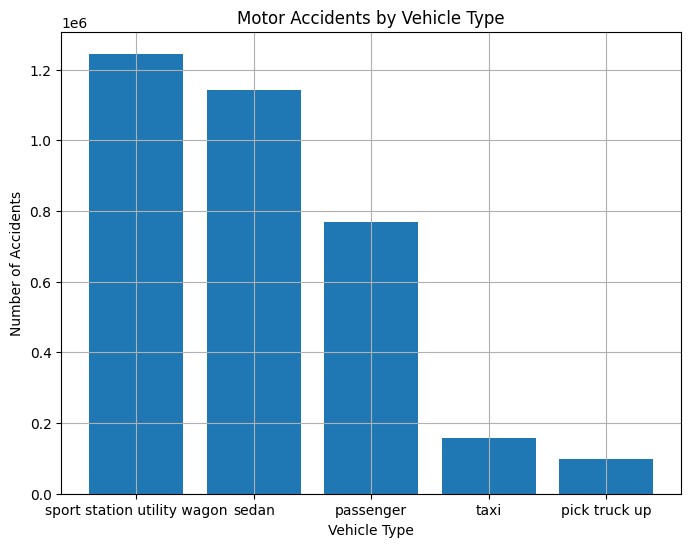

Total contributing factors: 1665330
Top 5 most common factors: Driver Inattention/Distraction    551911
Failure to Yield Right-of-Way     150659
Following Too Closely             142259
Backing Unsafely                   89121
Passing or Lane Usage Improper     77418
Name: count, dtype: int64

Descriptive statistics for pedestrians injured:
Mean: 0.06
Median: 0.00
Mode: 0
Std Dev: 0.25
Min: 0
Max: 27
Range: 27
Total: 131533
Sample Size: 2213556

Descriptive statistics for pedestrians killed:
Mean: 0.00
Median: 0.00
Mode: 0
Std Dev: 0.03
Min: 0
Max: 6
Range: 6
Total: 1730
Sample Size: 2213556

Descriptive statistics for cyclists injured:
Mean: 0.03
Median: 0.00
Mode: 0
Std Dev: 0.17
Min: 0
Max: 4
Range: 4
Total: 64319
Sample Size: 2213556

Descriptive statistics for cyclists killed:
Mean: 0.00
Median: 0.00
Mode: 0
Std Dev: 0.01
Min: 0
Max: 2
Range: 2
Total: 277
Sample Size: 2213556

Descriptive statistics for motorists injured:
Mean: 0.23
Median: 0.00
Mode: 0
Std Dev: 0.68
Min: 0
Max: 4

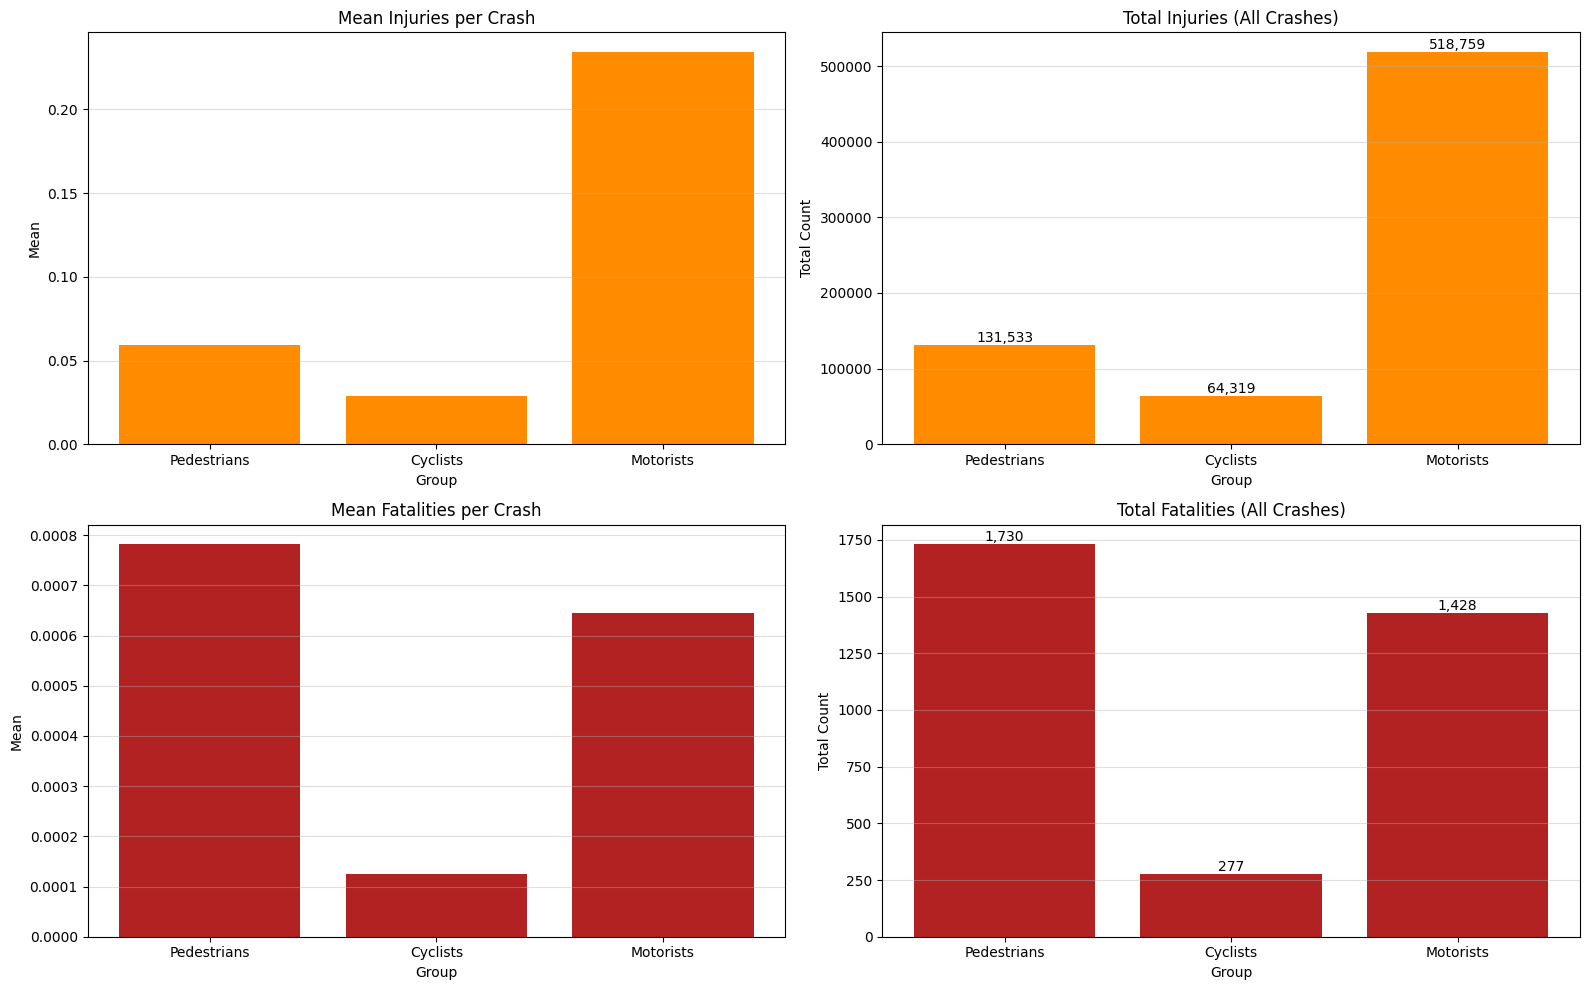

   CRASH DATE CRASH TIME   BOROUGH           ON STREET NAME CROSS STREET NAME  \
0  09/11/2021       2:39       NaN    WHITESTONE EXPRESSWAY         20 AVENUE   
1  03/26/2022      11:45       NaN  QUEENSBORO BRIDGE UPPER               NaN   
2  11/01/2023       1:29  BROOKLYN            OCEAN PARKWAY          AVENUE K   
3  06/29/2022       6:55       NaN       THROGS NECK BRIDGE               NaN   
4  09/21/2022      13:21       NaN          BROOKLYN BRIDGE               NaN   

  OFF STREET NAME  NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  \
0             NaN                        2.0                       0.0   
1             NaN                        1.0                       0.0   
2             NaN                        1.0                       0.0   
3             NaN                        0.0                       0.0   
4             NaN                        0.0                       0.0   

   NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  ... 

In [ ]:
def main():

    # loading in and cleaning data
    data = load_data("/content/drive/My Drive/FL-25/DS 2500/final project/"
                    "collisions.csv")
    data = clean_data(data)
    print(data.head())

    # analyzing time of day
    morning, afternoon, evening, night, all_times = time_of_day(data)

    # analyzing time of year
    winter, spring, summer, fall, all_seasons = time_of_year(data)

    # analyzing and visualizing borough
    bor = borough(data)
    borough_vis(bor)

    # analyzing intersection
    intersect = intersection(data)

    # analyzing and visualizing vehicle type
    vehicle_types = vehicle_type(data)
    vehicle_type_vis(vehicle_types)

    # analyzing contributing factors
    cont_fact_cols = ["CONTRIBUTING FACTOR VEHICLE 1",
                      "CONTRIBUTING FACTOR VEHICLE 2",
                      "CONTRIBUTING FACTOR VEHICLE 3",
                      "CONTRIBUTING FACTOR VEHICLE 4",
                      "CONTRIBUTING FACTOR VEHICLE 5"]

    total_factors, factors_freq = cont_facts(data, cont_fact_cols)
    print("Total contributing factors:", total_factors)
    print("Top 5 most common factors:", factors_freq.head())

    # analyzing and visualizing type of casualty
    categories = {"pedestrians injured": "NUMBER OF PEDESTRIANS INJURED",
                  "pedestrians killed": "NUMBER OF PEDESTRIANS KILLED",
                  "cyclists injured": "NUMBER OF CYCLIST INJURED",
                  "cyclists killed": "NUMBER OF CYCLIST KILLED",
                  "motorists injured": "NUMBER OF MOTORIST INJURED",
                  "motorists killed": "NUMBER OF MOTORIST KILLED",
                  "people injured": "NUMBER OF PERSONS INJURED",
                  "people killed": "NUMBER OF PERSONS KILLED"}

    for cat_name, col_name in categories.items():
        stats = descriptives(data, col_name)
        print_stats(cat_name, stats)

    type_casualty_vis(data)

    print(data.head())
main()